# API 1 ML CLASIFICACION Y REGRESION 

### CONSIGNA
A continuación, debemos reconocer las librerías necesarias para llevar a cabo la transformación de los datos en un data frame. También será necesario trabajar con un conjunto de pruebas equivalente al 20 % del total de los datos.
Es de suma importancia reconocer el número total de observaciones que cuentan con datos perdidos en el data set y con los datos nulos.
La primera parte del estudio previo estará compuesto por la matriz de correlación con las variables con una correlación superior al 60 % (equivalente a 0.60).

#### 1 -Librerias necesarias para esta API

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

%matplotlib inline

#### 2 - Carga de data set y conversión a dataa frame

In [5]:
# Carga el archivo (ajusta el nombre si usas Excel: pd.read_excel)
datos = pd.read_csv('AmesHousing.csv')

print(f"Dimensiones del dataset: {datos.shape}\n")  # Debería ser (2930, 82) aprox.
print(datos)  # Para ver todas las columnas

Dimensiones del dataset: (2930, 82)

      Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0         1  526301100           20        RL         141.0     31770   Pave   
1         2  526350040           20        RH          80.0     11622   Pave   
2         3  526351010           20        RL          81.0     14267   Pave   
3         4  526353030           20        RL          93.0     11160   Pave   
4         5  527105010           60        RL          74.0     13830   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2925   2926  923275080           80        RL          37.0      7937   Pave   
2926   2927  923276100           20        RL           NaN      8885   Pave   
2927   2928  923400125           85        RL          62.0     10441   Pave   
2928   2929  924100070           20        RL          77.0     10010   Pave   
2929   2930  924151050           60        RL          74.0      9627   Pave   

  

#### 3 - Código completo y detallado para identificar cuales observaciones tienen datos perdidos

In [6]:

# ------------------------------------------------------------------
# A) Número TOTAL de observaciones que tienen AL MENOS un dato nulo
# ------------------------------------------------------------------

obs_con_missing = datos.isnull().any(axis=1).sum()
total_obs = len(datos)

print(f"✅ Observaciones TOTALES en el dataset: {total_obs}")
print(f"🔴 Observaciones con al MENOS un dato perdido: {obs_con_missing}")
print(f"   Porcentaje: {obs_con_missing / total_obs:.1%}")

# Resultado típico que verás:
# Observaciones con al MENOS un dato perdido: ~2.927 de 2.930 (99.9%)
# → Casi TODAS las filas tienen al menos un NA (por las columnas de “sin piscina”, “sin garaje”, etc.)

✅ Observaciones TOTALES en el dataset: 2930
🔴 Observaciones con al MENOS un dato perdido: 2930
   Porcentaje: 100.0%


In [7]:
# ------------------------------------------------------------------
# B) ¿CUÁLES filas específicas tienen datos perdidos?
# ------------------------------------------------------------------

# Crear máscara booleana (True = tiene al menos un nulo)
filas_con_missing = datos.isnull().any(axis=1)

# 1. Lista de índices (números de fila) que tienen missing
#indices_missing = datos[filas_con_missing].index.tolist()

#print(f"\n📋 Primeros 20 índices de filas con datos perdidos:")
#print(indices_missing[:20])

# 2. Ver las filas completas que tienen missing (solo las primeras 5 para no saturar la pantalla)
print("\n🔍 Ejemplo de las primeras 5 filas con missing:")
print(datos[filas_con_missing].head())

# 3. Ver CUÁNTOS valores nulos tiene CADA fila (muy útil)
datos['n_missing'] = datos.isnull().sum(axis=1)          # columna temporal

print("\n📊 Filas con MÁS valores nulos (top 10):")
print(datos[['n_missing']].sort_values(by='n_missing', ascending=False).head(10))

# Eliminar la columna temporal
datos.drop(columns=['n_missing'], inplace=True)


🔍 Ejemplo de las primeras 5 filas con missing:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold

### Información adicional. 
#### Que significa este paso, por qué es importante en un proyecto de regresión lineal para precios inmobiliarios (como el que estamos armando para Trump and Co.), y cómo identificamos cuáles observaciones (es decir, qué filas específicas) tienen datos perdidos o nulos.

##### 1. ¿Qué son los “datos perdidos” en este contexto?
* En Pandas, un valor perdido se representa como:

    * NaN (Not a Number) → valor numérico nulo.
    * None o NaT (para fechas).

En el Ames Housing Dataset (2.930 observaciones × 82 columnas), los valores nulos NO son siempre errores.
Dean De Cock diseñó el dataset de forma que muchos “NA” tienen significado semántico muy útil para predecir el precio:

 | Columna | Qué significa NA | Ejemplo de interpretación inmobiliaria |
|---------|----------------|------------------------------------------|
| PoolQC | No tiene piscina | La propiedad no tiene piscina de lujo |
| MiscFeature | No tiene característica miscelánea | No tiene ascensor, pista de tenis, etc. |
| Alley | No tiene callejón | No tiene acceso por callejón privado |
| Fence | No tiene cerca | No tiene cerco perimetral |
| FireplaceQu | No tiene chimenea | Propiedad sin chimenea |
| GarageType / GarageFinish / GarageQual / etc. | No tiene garaje | La casa no incluye garaje |
| LotFrontage | Frente de lote desconocido | Dato realmente perdido (este sí es “missing”) |


Importante para real estate: estos “NA” son información valiosa. Una casa sin piscina suele valer menos que una con piscina. Por eso no debemos eliminar las filas; debemos tratarlos como una categoría (“Sin piscina”, “Sin garaje”, etc.).

#### 4 - Crear conjunto de prueba con el 20% de los datos

In [8]:
# Separar features y target
X = datos.drop('SalePrice', axis=1)
y = datos['SalePrice']

# Split 80% train - 20% test (estratificado por random_state para reproducibilidad)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20, 
    random_state=42
)

print(f"Train: {X_train.shape[0]} observaciones")
print(f"Test:  {X_test.shape[0]} observaciones")

Train: 2344 observaciones
Test:  586 observaciones


#### 5 - Identificar observaciones con datos perdidos o nulos

In [10]:
# a) Número total de observaciones que tienen AL MENOS un valor nulo
obs_con_missing = datos.isnull().any(axis=1).sum()
print(f"Observaciones con al menos un dato perdido: {obs_con_missing} de {len(datos)} ({obs_con_missing/len(datos):.1%})")

# b) Cantidad de valores nulos por columna (muy útil para entender el dataset)
missing_por_columna = datos.isnull().sum().sort_values(ascending=False)
print(missing_por_columna[missing_por_columna > 0])  # Solo columnas con nulos

Observaciones con al menos un dato perdido: 2930 de 2930 (100.0%)
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Yr Blt      159
Garage Cond        159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Qual           80
Bsmt Cond           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
BsmtFin SF 1         1
BsmtFin SF 2         1
Garage Area          1
Garage Cars          1
Bsmt Unf SF          1
Electrical           1
dtype: int64


#### 6 - Matriz de corrrelación con variables > 0.60
Nos interesa principalmente la correlación con la variable objetivo SalePrice, pero también entre features para detectar multicolinealidad.

Variables con |corr| > 0.60 con SalePrice:
 SalePrice        1.000000
Overall Qual     0.799262
Gr Liv Area      0.706780
Garage Cars      0.647877
Garage Area      0.640401
Total Bsmt SF    0.632280
1st Flr SF       0.621676
Name: SalePrice, dtype: float64


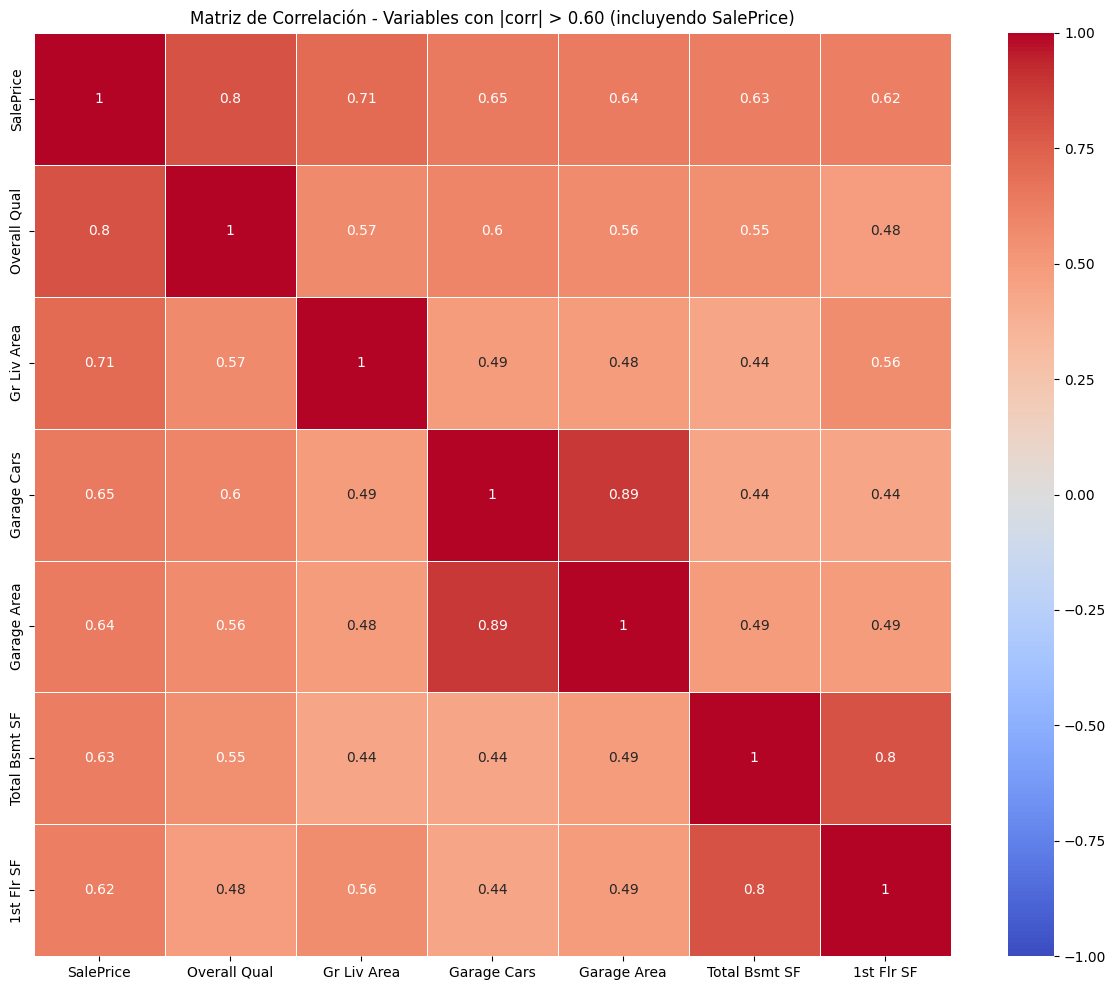

In [11]:
# Solo columnas numéricas
numeric_cols = datos.select_dtypes(include=[np.number]).columns

# Matriz de correlación completa
corr_matrix = datos[numeric_cols].corr()

# a) Variables con correlación absoluta > 0.60 con SalePrice
corr_con_target = corr_matrix['SalePrice'].abs().sort_values(ascending=False)
variables_fuertes = corr_con_target[corr_con_target > 0.60]
print("Variables con |corr| > 0.60 con SalePrice:\n", variables_fuertes)

# b) Matriz de correlación visual (heatmap) solo de las variables fuertes
variables_fuertes_list = variables_fuertes.index.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix.loc[variables_fuertes_list, variables_fuertes_list],
    annot=True, 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    center=0,
    linewidths=0.5
)
plt.title('Matriz de Correlación - Variables con |corr| > 0.60 (incluyendo SalePrice)')
plt.tight_layout()
plt.show()